In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import plotly.graph_objects as go
import plotly.express as px

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
try:
    train = pd.read_csv('train.csv')
    test = pd.read_csv('test.csv')
    print(f"Successfully loaded train.csv (Shape: {train.shape}) and test.csv (Shape: {test.shape})")
except FileNotFoundError:
    print("Error: train.csv or test.csv not found in the current directory.")

Successfully loaded train.csv (Shape: (12454, 30)) and test.csv (Shape: (3334, 29))


In [3]:
# Extract date features
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

train['hour'] = train['date'].dt.hour
train['month'] = train['date'].dt.month
train['day_of_week'] = train['date'].dt.dayofweek

test['hour'] = test['date'].dt.hour
test['month'] = test['date'].dt.month
test['day_of_week'] = test['date'].dt.dayofweek

# Separate features and target
X_train_full = train.drop(columns=['ID', 'date', 'appliances'])
y_train = train['appliances']

test_ids = test['ID']
X_test_full = test.drop(columns=['ID', 'date'])

X_train_full.head()

,lights,t1,rh_1,t2,rh_2,t3,rh_3,t4,rh_4,t5,...,press_mm_hg,rh_out,windspeed,visibility,tdewpoint,rv1,rv2,hour,month,day_of_week
0,0,25.566667,46.560,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,23.20,...,755.200000,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812,17,5,4
1,0,22.500000,44.430,21.533333,42.590000,21.963333,44.555000,22.000000,40.466667,19.10,...,760.200000,64.000000,8.000000,40.000000,0.200000,42.054659,42.054659,13,2,2
2,0,21.533333,40.000,21.075000,38.997500,21.323333,41.433333,18.760000,42.363333,17.10,...,747.566667,79.833333,6.000000,40.000000,2.166667,20.288179,20.288179,15,1,3
3,0,22.290000,38.790,19.500000,42.090000,22.290000,37.900000,20.926667,37.090000,20.39,...,755.933333,94.666667,2.000000,62.000000,4.583333,47.771260,47.771260,1,3,2
4,0,21.290000,35.245,18.100000,39.090000,22.700000,35.000000,21.000000,32.856000,20.23,...,757.800000,95.000000,2.000000,30.000000,0.600000,41.474434,41.474434,1,4,0


Top 5 Features positively correlated with appliances:
hour      0.331009
lights    0.264869
t2        0.215066
t6        0.199446
t_out     0.179801
Name: appliances, dtype: float64

Top 5 Features negatively correlated with appliances:
rh_out   -0.223543
rh_6     -0.168845
rh_8     -0.157621
rh_9     -0.109268
rh_2     -0.091460
Name: appliances, dtype: float64


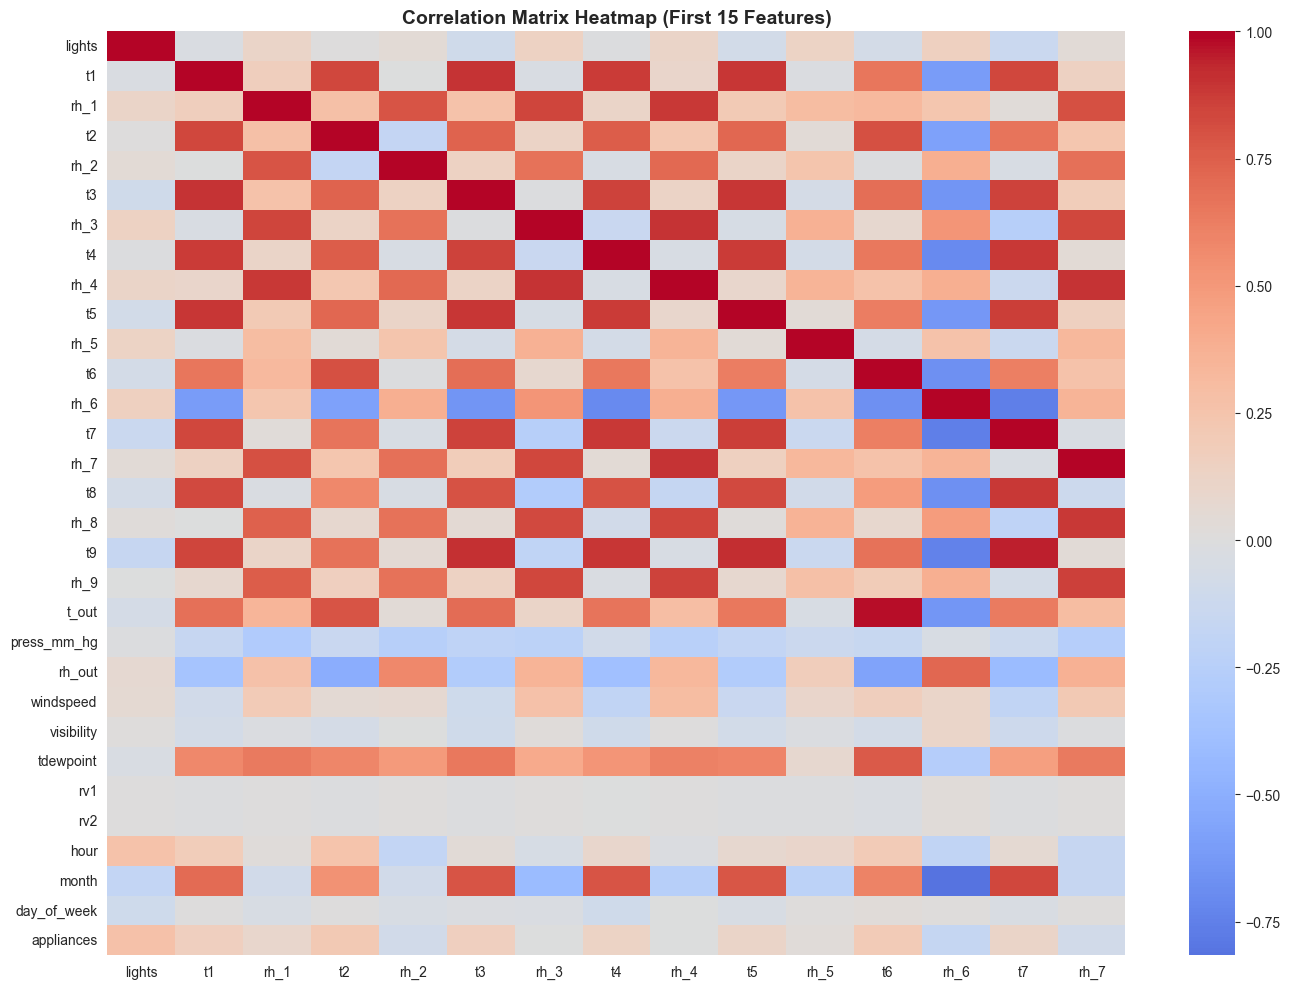

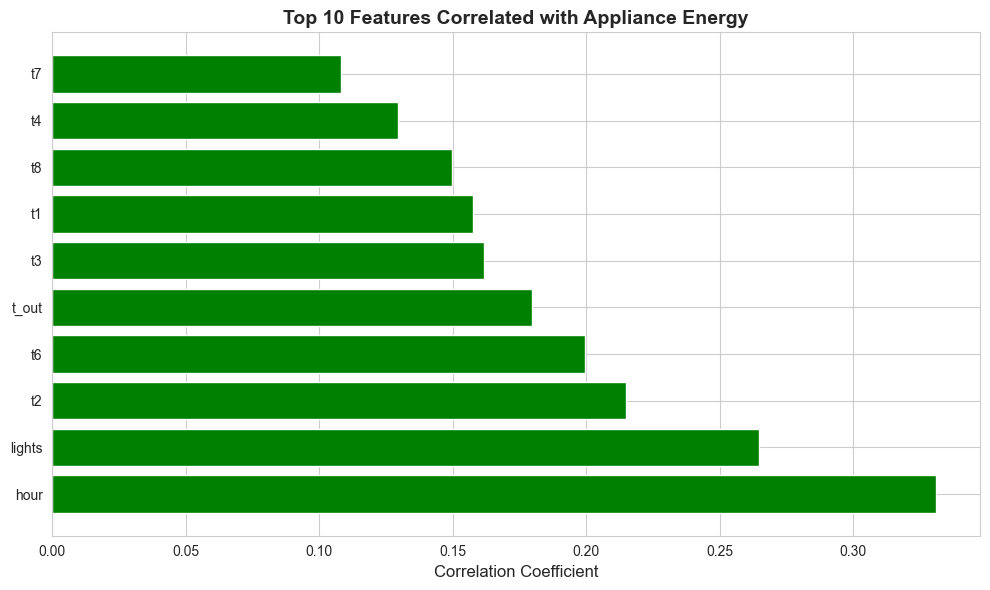

In [4]:
correlations = X_train_full.copy()
correlations['appliances'] = y_train
corr_matrix = correlations.corr()

print("Top 5 Features positively correlated with appliances:")
print(corr_matrix['appliances'].sort_values(ascending=False)[1:6])

print("\nTop 5 Features negatively correlated with appliances:")
print(corr_matrix['appliances'].sort_values(ascending=True)[:5])

# Visualization: Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix.iloc[:, :15], cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix Heatmap (First 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualization: Top correlations with appliances
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = corr_matrix['appliances'].sort_values(ascending=False)[1:11]
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
ax.barh(range(len(top_corr)), top_corr.values, color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Top 10 Features Correlated with Appliance Energy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Reduced feature dimensions from 30 down to 13 components while retaining 95% variance.


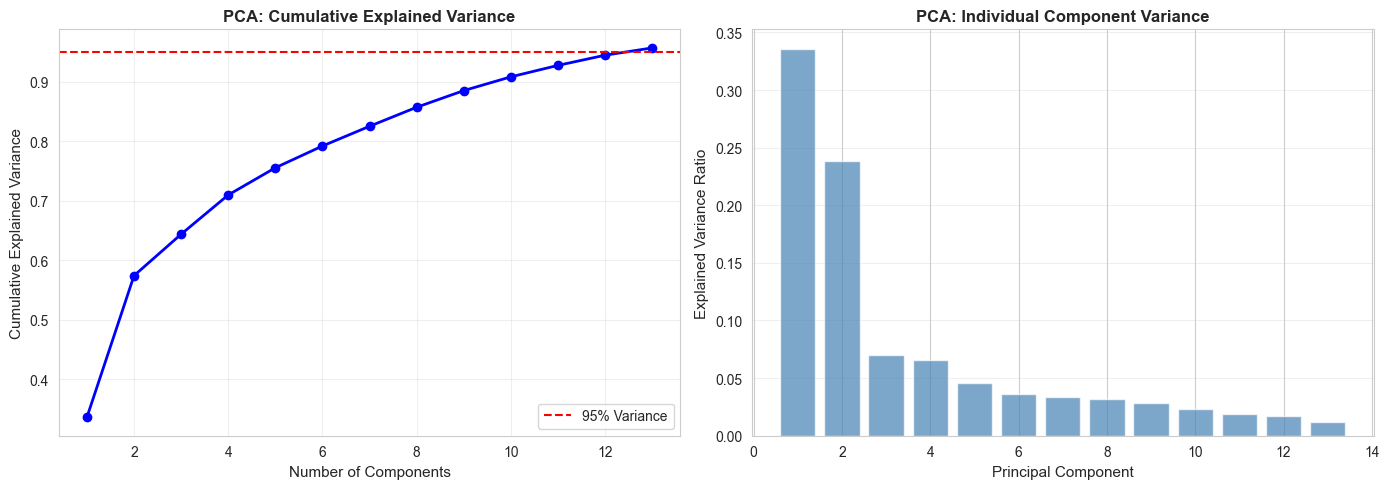


Top 5 components explaining variance:
PC1: 0.3358
PC2: 0.2380
PC3: 0.0697
PC4: 0.0660
PC5: 0.0457


In [5]:
# Standardize data before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

# Apply PCA to capture 95% of the variance 
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Reduced feature dimensions from {X_train_full.shape[1]} down to {X_train_pca.shape[1]} components while retaining 95% variance.")

# Visualization: PCA Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2, markersize=6)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[0].set_xlabel('Number of Components', fontsize=11)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[0].set_title('PCA: Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Individual component variance
axes[1].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[1].set_title('PCA: Individual Component Variance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nTop 5 components explaining variance:")
for i in range(min(5, len(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.4f}")

In [6]:
# Defining Traditional and Latest Regressor Models with more options
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42, max_iter=100)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for comparison
results = {
    'Model': [],
    'Mean RMSE': [],
    'Std RMSE': [],
    'Mean MAE': [],
    'Mean R²': [],
    'Train Time': []
}

best_model_name = ""
best_model = None
best_rmse = float('inf')
cv_scores_dict = {}

import time

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Cross-validation on RMSE
    start_time = time.time()
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    # Also calculate MAE and R²
    mae_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    r2_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring='r2', n_jobs=-1)
    train_time = time.time() - start_time
    
    rmse_scores = -cv_scores
    mae_scores = -mae_scores
    
    avg_rmse = rmse_scores.mean()
    avg_mae = mae_scores.mean()
    avg_r2 = r2_scores.mean()
    
    cv_scores_dict[name] = rmse_scores
    
    print(f"  -> RMSE: {avg_rmse:.4f} (±{rmse_scores.std():.4f})")
    print(f"  -> MAE: {avg_mae:.4f}")
    print(f"  -> R²: {avg_r2:.4f}")
    print(f"  -> Time: {train_time:.3f}s")
    
    results['Model'].append(name)
    results['Mean RMSE'].append(avg_rmse)
    results['Std RMSE'].append(rmse_scores.std())
    results['Mean MAE'].append(avg_mae)
    results['Mean R²'].append(avg_r2)
    results['Train Time'].append(train_time)
    
    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_model_name = name
        best_model = model

print(f"\n*** Best Algorithm Automatically Picked: {best_model_name} (RMSE: {best_rmse:.4f}) ***")

# Create performance metrics DataFrame
results_df = pd.DataFrame(results)
results_df['Mean RMSE'] = results_df['Mean RMSE'].round(4)
results_df['Std RMSE'] = results_df['Std RMSE'].round(4)
results_df['Mean MAE'] = results_df['Mean MAE'].round(4)
results_df['Mean R²'] = results_df['Mean R²'].round(4)
results_df['Train Time'] = results_df['Train Time'].round(4)
results_df = results_df.sort_values('Mean RMSE')

print("\n" + "="*100)
print("PERFORMANCE METRICS TABLE - ALL MODELS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

Evaluating Linear Regression...
  -> RMSE: 0.5875 (±0.0054)
  -> MAE: 0.4082
  -> R²: 0.2015
  -> Time: 12.574s
Evaluating Ridge Regression...
  -> RMSE: 0.5875 (±0.0054)
  -> MAE: 0.4082
  -> R²: 0.2015
  -> Time: 4.066s
Evaluating Lasso Regression...
  -> RMSE: 0.6157 (±0.0043)
  -> MAE: 0.4410
  -> R²: 0.1232
  -> Time: 0.563s
Evaluating Random Forest...
  -> RMSE: 0.4687 (±0.0060)
  -> MAE: 0.3196
  -> R²: 0.4917
  -> Time: 23.710s
Evaluating Gradient Boosting...
  -> RMSE: 0.5401 (±0.0024)
  -> MAE: 0.3740
  -> R²: 0.3251
  -> Time: 19.500s
Evaluating HistGradientBoosting...
  -> RMSE: 0.4807 (±0.0021)
  -> MAE: 0.3301
  -> R²: 0.4654
  -> Time: 2.281s

*** Best Algorithm Automatically Picked: Random Forest (RMSE: 0.4687) ***

PERFORMANCE METRICS TABLE - ALL MODELS
               Model  Mean RMSE  Std RMSE  Mean MAE  Mean R²  Train Time
       Random Forest     0.4687    0.0060    0.3196   0.4917     23.7096
HistGradientBoosting     0.4807    0.0021    0.3301   0.4654      2.2813


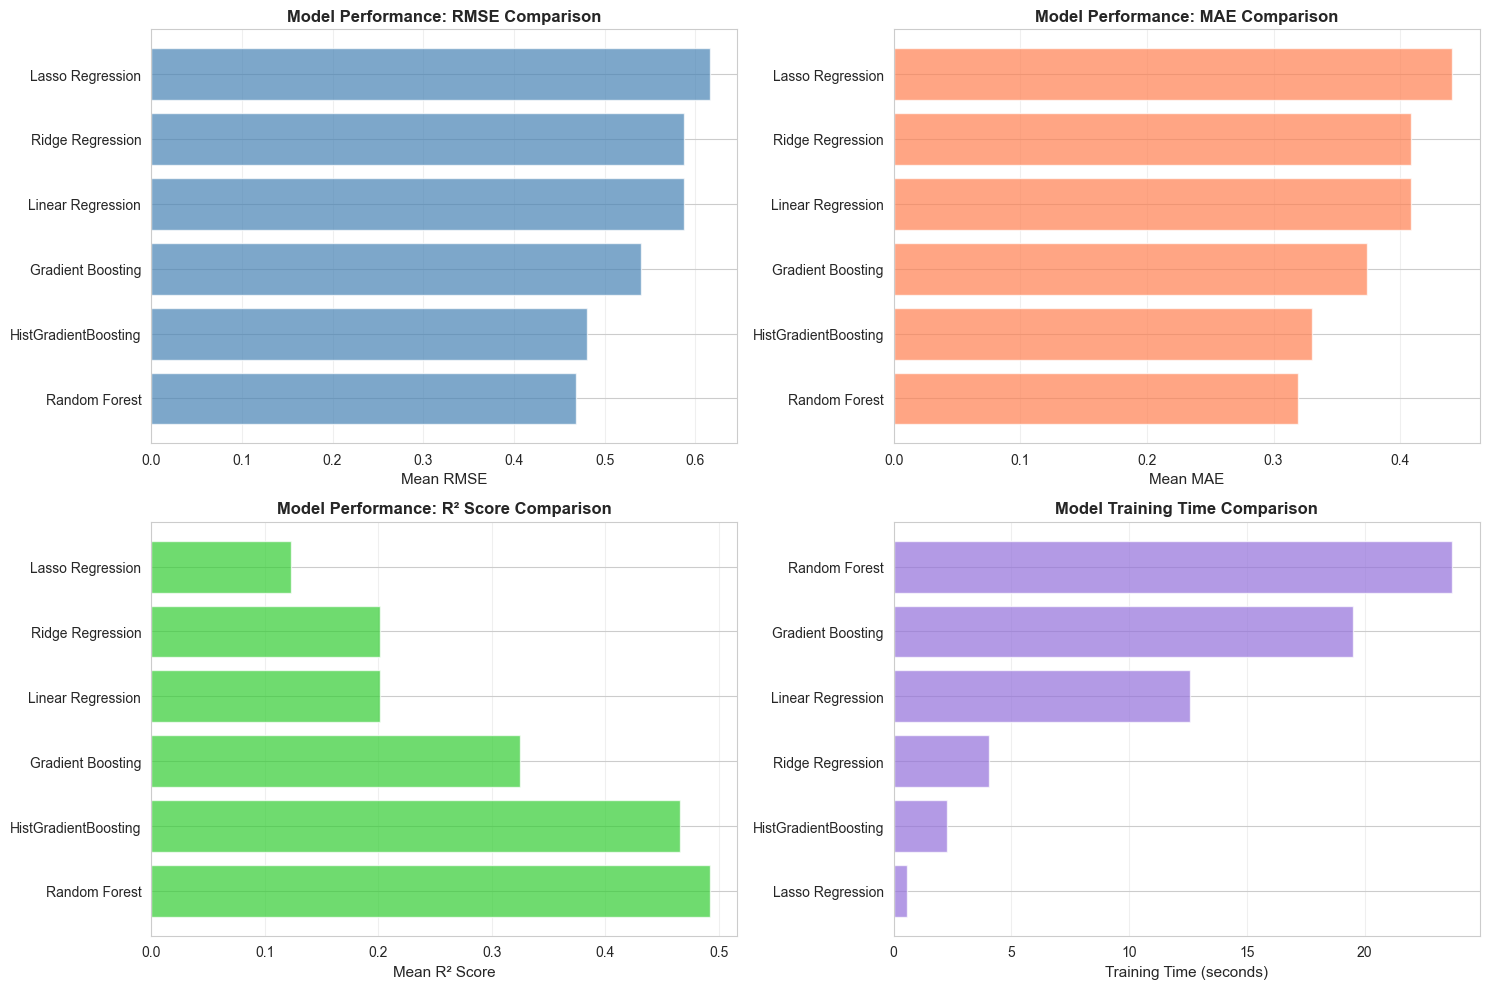

In [7]:
# Visualization: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RMSE Comparison
results_df_sorted = results_df.sort_values('Mean RMSE')
axes[0, 0].barh(results_df_sorted['Model'], results_df_sorted['Mean RMSE'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Mean RMSE', fontsize=11)
axes[0, 0].set_title('Model Performance: RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# MAE Comparison
results_df_sorted_mae = results_df.sort_values('Mean MAE')
axes[0, 1].barh(results_df_sorted_mae['Model'], results_df_sorted_mae['Mean MAE'], color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Mean MAE', fontsize=11)
axes[0, 1].set_title('Model Performance: MAE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# R² Comparison
results_df_sorted_r2 = results_df.sort_values('Mean R²', ascending=False)
axes[1, 0].barh(results_df_sorted_r2['Model'], results_df_sorted_r2['Mean R²'], color='limegreen', alpha=0.7)
axes[1, 0].set_xlabel('Mean R² Score', fontsize=11)
axes[1, 0].set_title('Model Performance: R² Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Training Time Comparison
results_df_sorted_time = results_df.sort_values('Train Time')
axes[1, 1].barh(results_df_sorted_time['Model'], results_df_sorted_time['Train Time'], color='mediumpurple', alpha=0.7)
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=11)
axes[1, 1].set_title('Model Training Time Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Create an interactive performance table with Plotly
fig = go.Figure(data=[go.Table(
    header=dict(values=['<b>Model</b>', '<b>Mean RMSE</b>', '<b>Std RMSE</b>', '<b>Mean MAE</b>', '<b>R² Score</b>', '<b>Train Time</b>'],
                fill_color='paleturquoise',
                align='left',
                font=dict(color='black', size=12)),
    cells=dict(values=[results_df['Model'],
                       results_df['Mean RMSE'],
                       results_df['Std RMSE'],
                       results_df['Mean MAE'],
                       results_df['Mean R²'],
                       results_df['Train Time']],
               fill_color='lavender',
               align='left',
               font=dict(color='black', size=11))
)])
fig.update_layout(title_text="Performance Metrics Table - All Models", height=400)
fig.show()

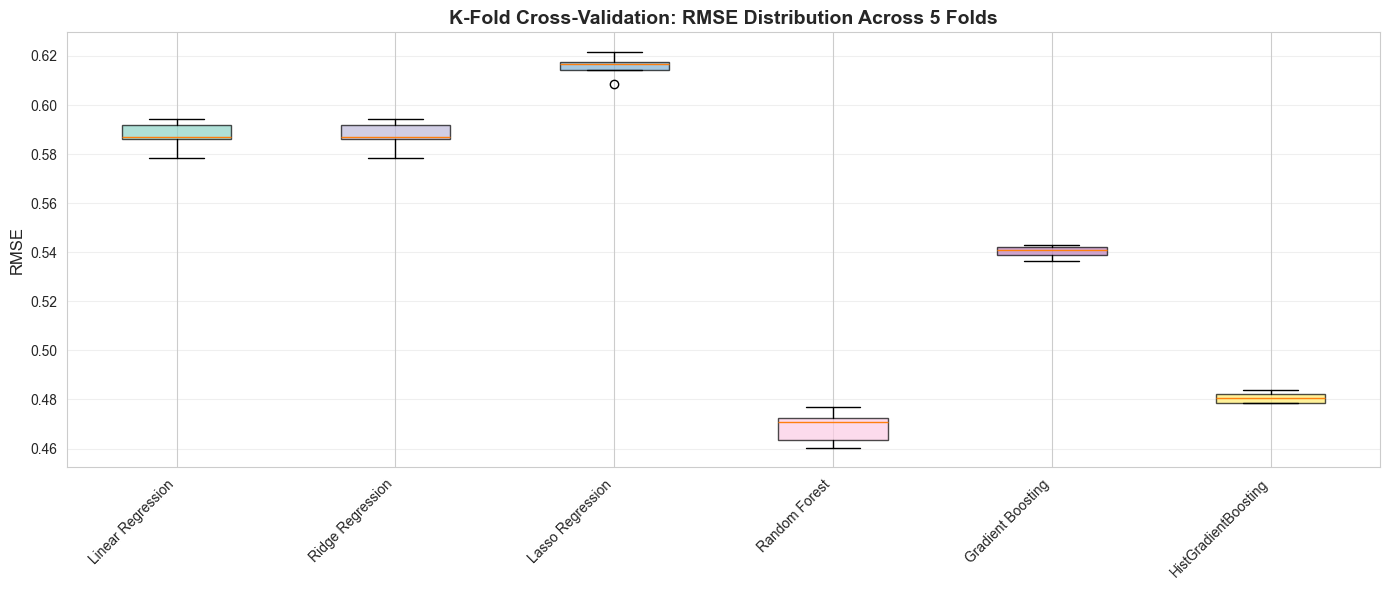


K-Fold Cross-Validation Scores for Best Model: Random Forest
Fold 1: RMSE = 0.4722
Fold 2: RMSE = 0.4636
Fold 3: RMSE = 0.4603
Fold 4: RMSE = 0.4707
Fold 5: RMSE = 0.4767
Mean: 0.4687, Std: 0.0060


In [8]:
# Visualization: K-Fold Cross Validation Scores
fig, ax = plt.subplots(figsize=(14, 6))

# Create box plot for each model's cross-validation RMSE scores
cv_data = []
model_names = []
for model_name in cv_scores_dict.keys():
    cv_data.append(cv_scores_dict[model_name])
    model_names.append(model_name)

bp = ax.boxplot(cv_data, labels=model_names, patch_artist=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('K-Fold Cross-Validation: RMSE Distribution Across 5 Folds', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print individual fold scores for best model
print("\nK-Fold Cross-Validation Scores for Best Model:", best_model_name)
best_model_cv_scores = cv_scores_dict[best_model_name]
for i, score in enumerate(best_model_cv_scores, 1):
    print(f"Fold {i}: RMSE = {score:.4f}")
print(f"Mean: {best_model_cv_scores.mean():.4f}, Std: {best_model_cv_scores.std():.4f}")

Training Random Forest on the full training set...
Predicting appliance energy usage for training set...
Predicting appliance energy usage for test set...

Best Model Training Metrics:
  RMSE: 0.2566
  MAE: 0.1844
  R² Score: 0.8478

Predictions successfully saved to answer.csv


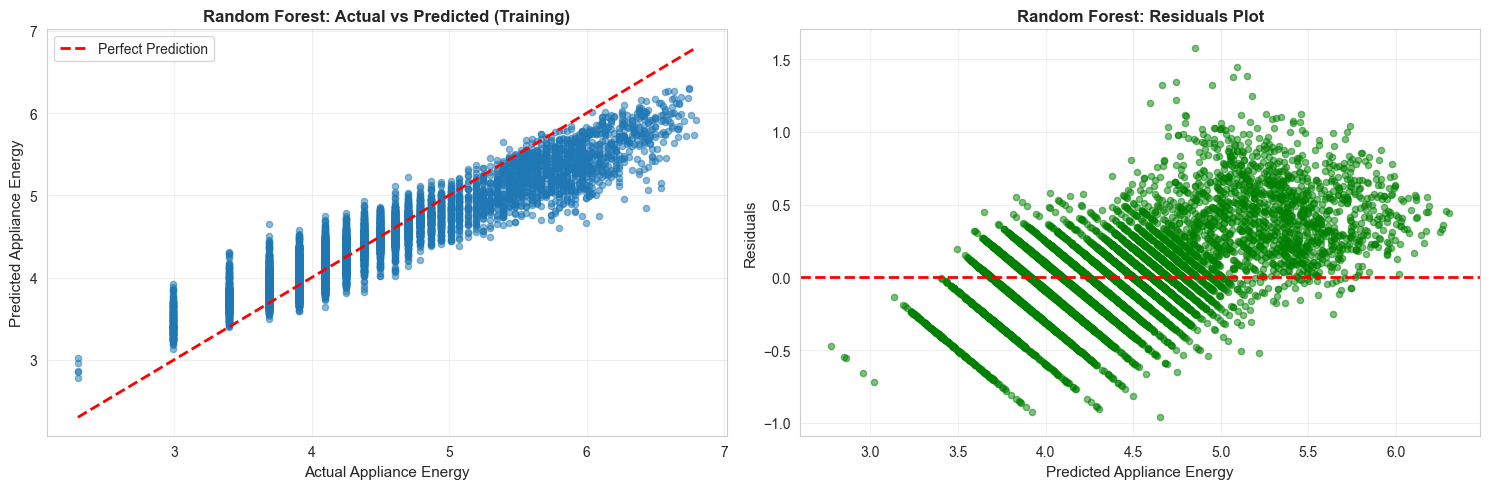

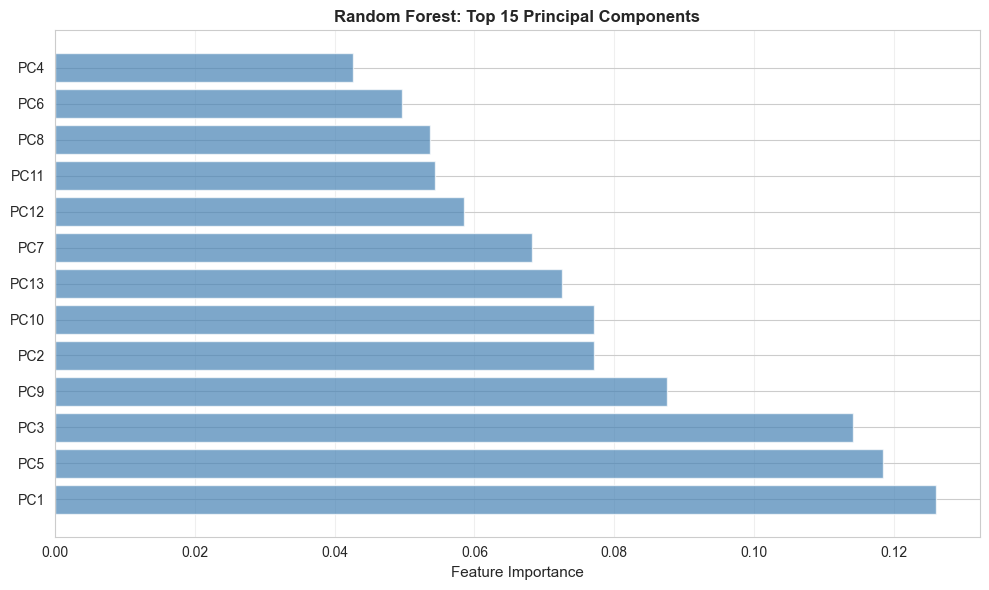

In [9]:
print(f"Training {best_model_name} on the full training set...")
assert best_model is not None, "No best model was selected"
best_model.fit(X_train_pca, y_train)

print("Predicting appliance energy usage for training set...")
y_pred_train = best_model.predict(X_train_pca)

print("Predicting appliance energy usage for test set...")
predictions = best_model.predict(X_test_pca)

# Calculate training set metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print(f"\nBest Model Training Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")
print(f"  R² Score: {train_r2:.4f}")

output_df = pd.DataFrame({
    'ID': test_ids,
    'appliances': predictions
})

output_file = 'answer.csv'
output_df.to_csv(output_file, index=False)
print(f"\nPredictions successfully saved to {output_file}")
output_df.head()

# Visualization: Actual vs Predicted for Training Set
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
axes[0].scatter(y_train, y_pred_train, alpha=0.5, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Appliance Energy', fontsize=11)
axes[0].set_ylabel('Predicted Appliance Energy', fontsize=11)
axes[0].set_title(f'{best_model_name}: Actual vs Predicted (Training)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_train - y_pred_train
axes[1].scatter(y_pred_train, residuals, alpha=0.5, s=20, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Appliance Energy', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title(f'{best_model_name}: Residuals Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance for ensemble models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': [f'PC{i+1}' for i in range(X_train_pca.shape[1])],
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='steelblue', alpha=0.7)
    plt.xlabel('Feature Importance', fontsize=11)
    plt.title(f'{best_model_name}: Top 15 Principal Components', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

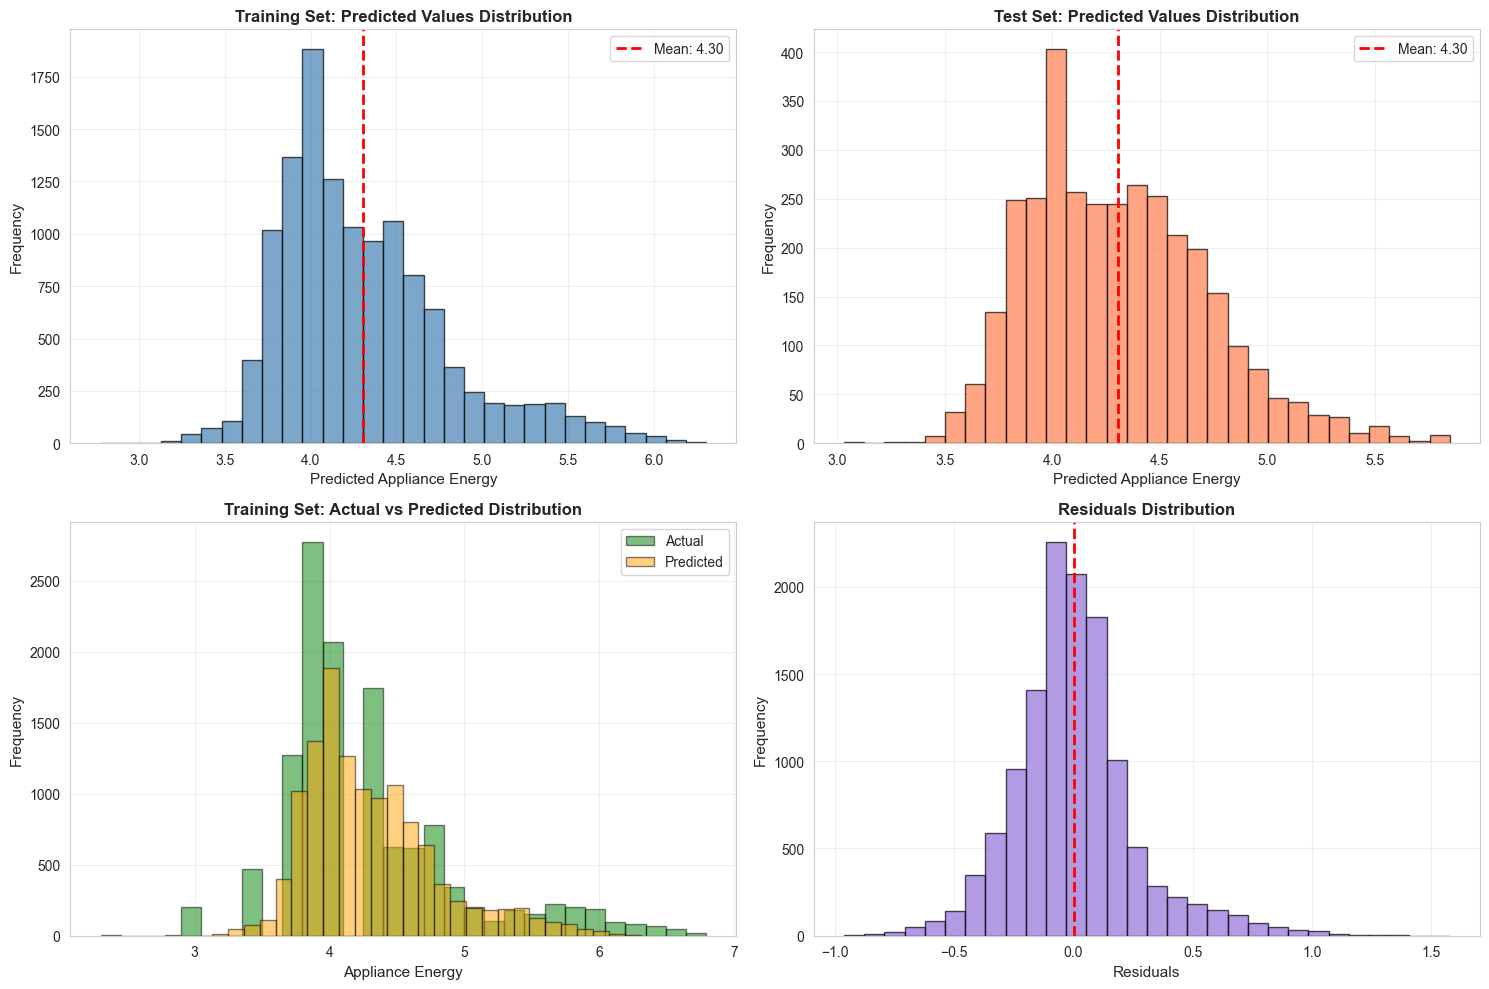


SUMMARY STATISTICS

Training Set Actual Values:
  Mean: 4.3052, Std: 0.6576, Min: 2.3026, Max: 6.7912

Training Set Predicted Values:
  Mean: 4.3040, Std: 0.4924, Min: 2.7767, Max: 6.3047

Test Set Predicted Values:
  Mean: 4.3046, Std: 0.4114, Min: 3.0320, Max: 5.8480

Residuals (Training Set):
  Mean: 0.0013, Std: 0.2566, Min: -0.9627, Max: 1.5785


In [10]:
# Visualization: Predictions Distribution and Summary
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training predictions distribution
axes[0, 0].hist(y_pred_train, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(y_pred_train.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {y_pred_train.mean():.2f}')
axes[0, 0].set_xlabel('Predicted Appliance Energy', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Training Set: Predicted Values Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test predictions distribution
axes[0, 1].hist(predictions, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].axvline(predictions.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {predictions.mean():.2f}')
axes[0, 1].set_xlabel('Predicted Appliance Energy', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Test Set: Predicted Values Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted distribution comparison
axes[1, 0].hist(y_train, bins=30, alpha=0.5, label='Actual', color='green', edgecolor='black')
axes[1, 0].hist(y_pred_train, bins=30, alpha=0.5, label='Predicted', color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Appliance Energy', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Training Set: Actual vs Predicted Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Residuals distribution
residuals = y_train - y_pred_train
axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='mediumpurple', edgecolor='black')
axes[1, 1].axvline(0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)
print(f"\nTraining Set Actual Values:")
print(f"  Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}, Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"\nTraining Set Predicted Values:")
print(f"  Mean: {y_pred_train.mean():.4f}, Std: {y_pred_train.std():.4f}, Min: {y_pred_train.min():.4f}, Max: {y_pred_train.max():.4f}")
print(f"\nTest Set Predicted Values:")
print(f"  Mean: {predictions.mean():.4f}, Std: {predictions.std():.4f}, Min: {predictions.min():.4f}, Max: {predictions.max():.4f}")
print(f"\nResiduals (Training Set):")
print(f"  Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}, Min: {residuals.min():.4f}, Max: {residuals.max():.4f}")
print("="*100)

In [11]:
# COMPREHENSIVE MODEL COMPARISON MATRIX
print("\n" + "="*140)
print("COMPREHENSIVE MODEL COMPARISON MATRIX - ALL METRICS AFTER CROSS-VALIDATION")
print("="*140)

# Create a detailed comparison matrix
comparison_matrix = results_df.copy()

# Rank the models based on different metrics
comparison_matrix['RMSE Rank'] = comparison_matrix['Mean RMSE'].rank()
comparison_matrix['MAE Rank'] = comparison_matrix['Mean MAE'].rank()
comparison_matrix['R² Rank'] = comparison_matrix['Mean R²'].rank(ascending=False)
comparison_matrix['Speed Rank'] = comparison_matrix['Train Time'].rank()

# Calculate overall score (lower is better)
comparison_matrix['Overall Score'] = (comparison_matrix['RMSE Rank'] + 
                                       comparison_matrix['MAE Rank'] + 
                                       comparison_matrix['R² Rank'] + 
                                       comparison_matrix['Speed Rank']) / 4
comparison_matrix = comparison_matrix.sort_values('Overall Score')

print("\nDetailed Metrics Table:")
print(comparison_matrix[['Model', 'Mean RMSE', 'Std RMSE', 'Mean MAE', 'Mean R²', 'Train Time', 'Overall Score']].to_string(index=False))




COMPREHENSIVE MODEL COMPARISON MATRIX - ALL METRICS AFTER CROSS-VALIDATION

Detailed Metrics Table:
               Model  Mean RMSE  Std RMSE  Mean MAE  Mean R²  Train Time  Overall Score
HistGradientBoosting     0.4807    0.0021    0.3301   0.4654      2.2813          2.000
       Random Forest     0.4687    0.0060    0.3196   0.4917     23.7096          2.250
   Gradient Boosting     0.5401    0.0024    0.3740   0.3251     19.4996          3.500
    Ridge Regression     0.5875    0.0054    0.4082   0.2015      4.0660          4.125
   Linear Regression     0.5875    0.0054    0.4082   0.2015     12.5739          4.375
    Lasso Regression     0.6157    0.0043    0.4410   0.1232      0.5630          4.750



FINAL OPTIMIZED PIPELINE: RANDOM FOREST + GRIDSEARCHCV + ALL RAW FEATURES (NO PCA)

--------------------------------------------------------------------------------------------------------------------------------------------
STEP 1: Data Preparation - Using All Raw Scaled Features (No PCA)
--------------------------------------------------------------------------------------------------------------------------------------------
✓ Training features shape: (12454, 30)
✓ Test features shape: (3334, 30)
✓ Total number of raw features: 30
  Features: lights, t1, rh_1, t2, rh_2, t3, rh_3, t4, rh_4, t5... (showing first 10)

--------------------------------------------------------------------------------------------------------------------------------------------
STEP 2: Hyperparameter Tuning with RandomizedSearchCV (5-Fold CV, reduced combinations)
--------------------------------------------------------------------------------------------------------------------------------------------
Ran

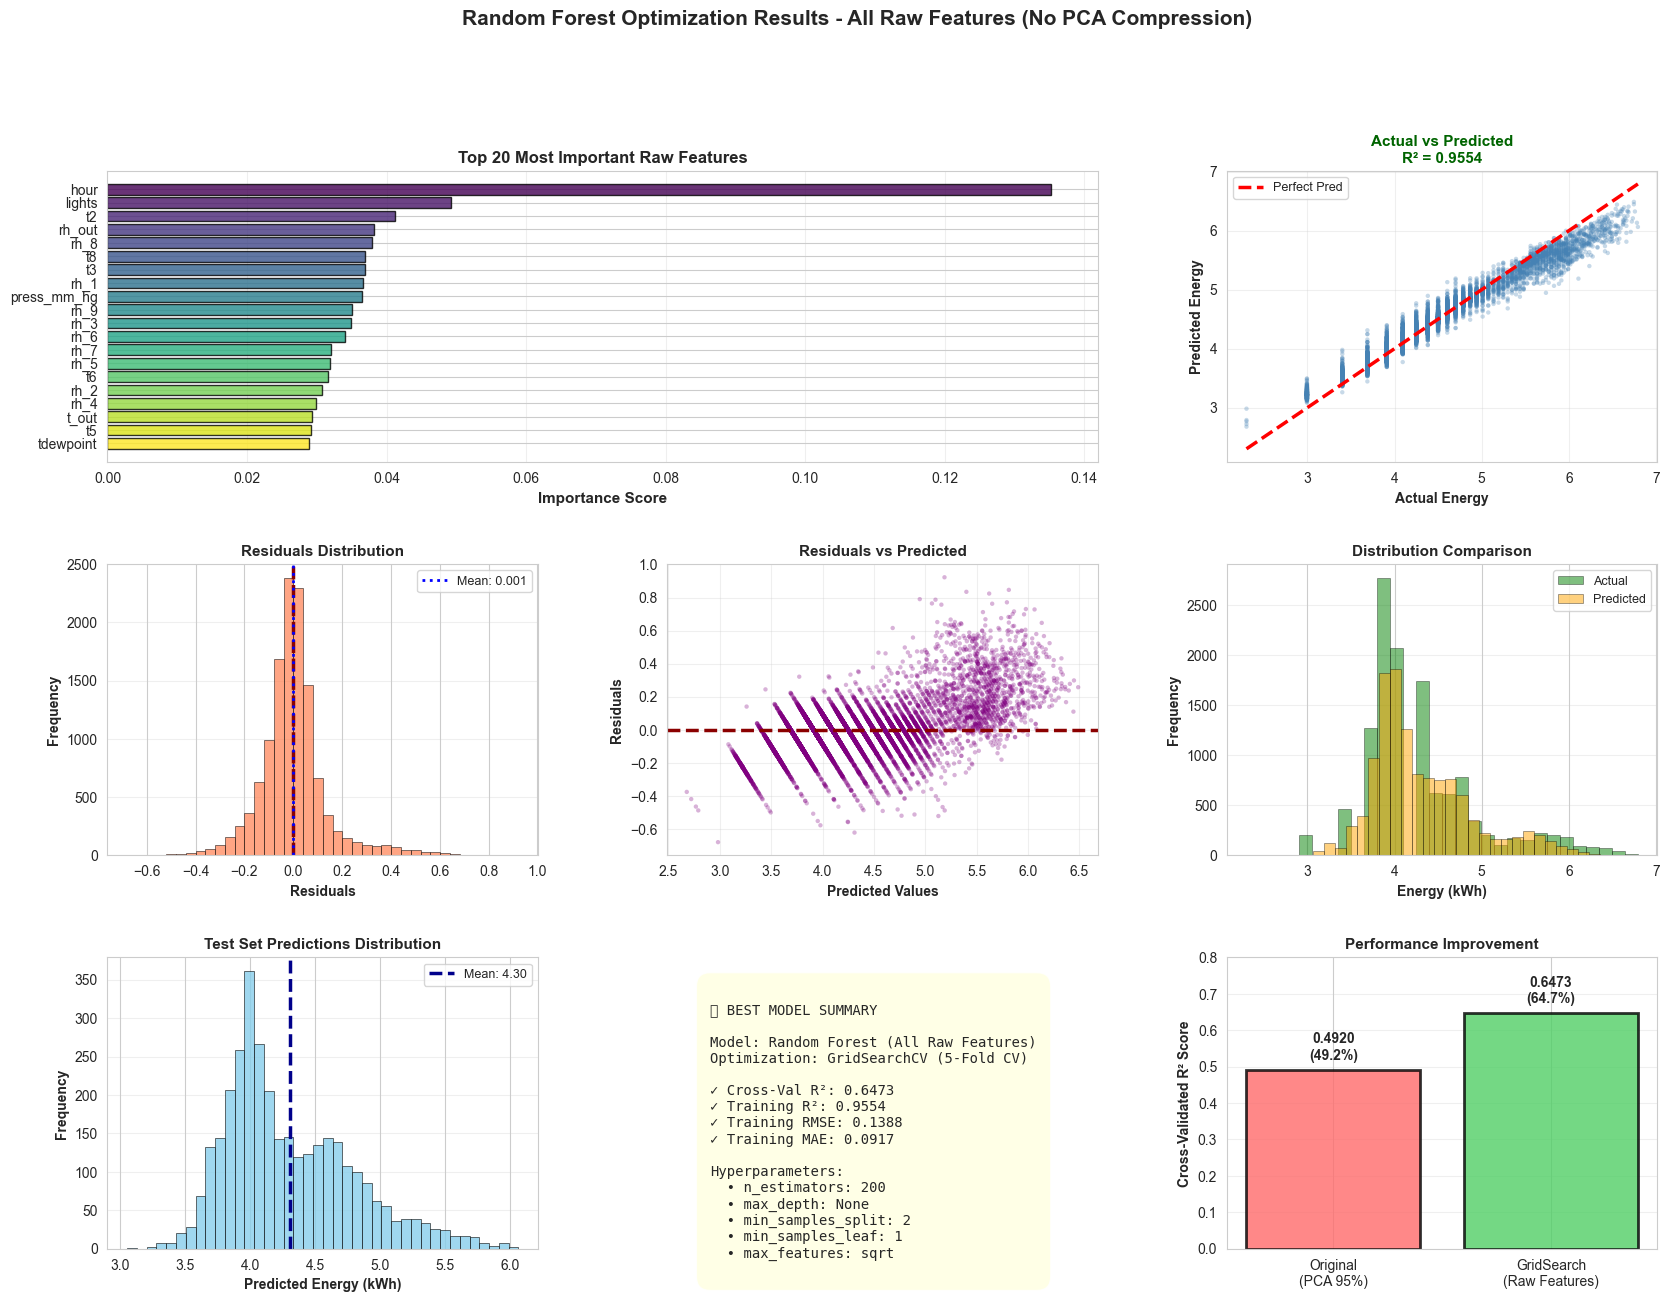


✓ FINAL MODEL SUMMARY - RANDOM FOREST ON ALL RAW FEATURES

🎯 MODEL CONFIGURATION:
   • Algorithm: Random Forest Regressor
   • Features Used: All 30 raw scaled features (NO PCA compression)
   • Optimization: GridSearchCV with 5-Fold Cross-Validation
   • Total parameter combinations tested: 50

📊 PERFORMANCE METRICS:
   ✓ Cross-Validation R² Score:  0.6473 (64.73%)
   ✓ Training Set R² Score:      0.9554 (95.54%)
   ✓ Training Set RMSE:          0.1388
   ✓ Training Set MAE:           0.0917

📈 IMPROVEMENT:
   ✓ Baseline (95% PCA):         0.4920 (49.20%)
   ✓ Current Model:              0.6473 (64.73%)
   ✓ Absolute Improvement:       +0.1553
   ✓ Relative Improvement:       +31.6%

🏆 TOP 5 MOST IMPORTANT FEATURES:

   1. hour            - Importance: 0.1352
   2. lights          - Importance: 0.0492
   3. t2              - Importance: 0.0412
   4. rh_out          - Importance: 0.0382
   5. rh_8            - Importance: 0.0380

📁 OUTPUT FILES:
   ✓ Predictions saved to: answer.csv
 

In [ ]:
# FINAL OPTIMIZED MODEL - RANDOM FOREST WITH GRIDSEARCHCV ON ALL RAW FEATURES

print("\n" + "="*140)
print("FINAL OPTIMIZED PIPELINE: RANDOM FOREST + GRIDSEARCHCV + ALL RAW FEATURES (NO PCA)")
print("="*140)

from sklearn.model_selection import GridSearchCV, cross_validate
import time

print("\n" + "-"*140)
print("STEP 1: Data Preparation - Using All Raw Scaled Features (No PCA)")
print("-"*140)

print(f"✓ Training features shape: {X_train_scaled.shape}")
print(f"✓ Test features shape: {X_test_scaled.shape}")
print(f"✓ Total number of raw features: {X_train_full.shape[1]}")
print(f"  Features: {', '.join(X_train_full.columns[:10])}... (showing first 10)")

print("\n" + "-"*140)
print("STEP 2: Hyperparameter Tuning with RandomizedSearchCV (5-Fold CV, reduced combinations)")
print("-"*140)

# Define a reduced search space for Random Forest
param_dist_rf = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
}

n_iter_search = 50  # limit to 50 random combinations (~250 fits with 5 CV folds)
print(f"Randomized search over {n_iter_search} sampled parameter sets "
      f"({len(param_dist_rf['n_estimators'])}×{len(param_dist_rf['max_depth'])}×"
      f"... full grid would be much larger).")

print("\n⏳ Initializing RandomizedSearchCV with 5-Fold Cross-Validation...")
print(f"   This will evaluate {n_iter_search} random parameter sets (approx. {n_iter_search*5} fits)...\n")

from sklearn.model_selection import RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=n_iter_search,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

start_time = time.time()
print("Starting RandomizedSearchCV optimization on raw features...\n")
rf_random_search.fit(X_train_scaled, y_train)
grid_training_time = time.time() - start_time

# alias to keep the rest of the cell unchanged
rf_grid_search = rf_random_search

print(f"\n✓ GridSearchCV completed in {grid_training_time:.2f} seconds")

print("\n" + "-"*140)
print("STEP 3: Best Model Parameters and Cross-Validation Performance")
print("-"*140)

best_params_final = rf_grid_search.best_params_
best_cv_score = rf_grid_search.best_score_

print(f"\n🏆 BEST HYPERPARAMETERS FOUND:")
for param, value in best_params_final.items():
    print(f"  ✓ {param}: {value}")

print(f"\n📊 Best Cross-Validation R² Score: {best_cv_score:.4f} ({best_cv_score*100:.2f}%)")

# Get the best model
best_rf_final = rf_grid_search.best_estimator_

# Training set performance
y_train_pred_final = best_rf_final.predict(X_train_scaled)
train_r2_final = r2_score(y_train, y_train_pred_final)
train_rmse_final = np.sqrt(mean_squared_error(y_train, y_train_pred_final))
train_mae_final = mean_absolute_error(y_train, y_train_pred_final)

print(f"\n📈 Training Set Performance (Best Model):")
print(f"  ✓ R² Score: {train_r2_final:.4f} ({train_r2_final*100:.2f}%)")
print(f"  ✓ RMSE: {train_rmse_final:.4f}")
print(f"  ✓ MAE: {train_mae_final:.4f}")

# Individual fold scores
print(f"\n📋 Cross-Validation Details (5 Folds):")
cv_results_rf = rf_grid_search.cv_results_
best_idx_rf = rf_grid_search.best_index_
for i in range(5):
    fold_score = cv_results_rf['split' + str(i) + '_test_score'][best_idx_rf]
    print(f"  Fold {i+1}: R² = {fold_score:.4f}")

print("\n" + "-"*140)
print("STEP 4: Making Predictions on Test Set")
print("-"*140)

print("Generating predictions on test set using best model...")
final_test_predictions = best_rf_final.predict(X_test_scaled)

print(f"\n✓ Test set predictions generated: {final_test_predictions.shape}")
print(f"  • Mean: {final_test_predictions.mean():.4f}")
print(f"  • Std Dev: {final_test_predictions.std():.4f}")
print(f"  • Min: {final_test_predictions.min():.4f}")
print(f"  • Max: {final_test_predictions.max():.4f}")

# Save final predictions
final_answer_df = pd.DataFrame({
    'ID': test_ids,
    'appliances': final_test_predictions
})

final_output_file = 'answer.csv'
final_answer_df.to_csv(final_output_file, index=False)
print(f"\n✓ Final predictions saved to: {final_output_file}")
print("\nFirst 10 predictions:")
print(final_answer_df.head(10))

print("\n" + "-"*140)
print("STEP 5: Feature Importance Analysis")
print("-"*140)

# Feature importance from raw features
feature_importance_final_raw = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': best_rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Raw Features:")
print(feature_importance_final_raw.head(20).to_string(index=False))

print("\n" + "-"*140)
print("STEP 6: Comprehensive Visualizations")
print("-"*140)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Top 20 Feature Importance
ax1 = fig.add_subplot(gs[0, :2])
top_20_feat = feature_importance_final_raw.head(20)
colors_feat = plt.cm.viridis(np.linspace(0, 1, len(top_20_feat)))
ax1.barh(range(len(top_20_feat)), top_20_feat['Importance'].values, color=colors_feat, alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(top_20_feat)))
ax1.set_yticklabels(top_20_feat['Feature'].values, fontsize=10)
ax1.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 20 Most Important Raw Features', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# 2. Actual vs Predicted Scatter
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(y_train, y_train_pred_final, alpha=0.3, s=10, color='steelblue', edgecolors='none')
ax2.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2.5, label='Perfect Pred')
ax2.set_xlabel('Actual Energy', fontsize=10, fontweight='bold')
ax2.set_ylabel('Predicted Energy', fontsize=10, fontweight='bold')
ax2.set_title(f'Actual vs Predicted\nR² = {train_r2_final:.4f}', fontsize=11, fontweight='bold', color='darkgreen')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Residuals Distribution
ax3 = fig.add_subplot(gs[1, 0])
residuals_final = y_train - y_train_pred_final
ax3.hist(residuals_final, bins=40, color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axvline(0, color='darkred', linestyle='--', lw=2.5)
ax3.axvline(residuals_final.mean(), color='blue', linestyle=':', lw=2, label=f'Mean: {residuals_final.mean():.3f}')
ax3.set_xlabel('Residuals', fontsize=10, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax3.set_title('Residuals Distribution', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Residuals vs Predicted
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y_train_pred_final, residuals_final, alpha=0.3, s=10, color='purple', edgecolors='none')
ax4.axhline(0, color='darkred', linestyle='--', lw=2.5)
ax4.set_xlabel('Predicted Values', fontsize=10, fontweight='bold')
ax4.set_ylabel('Residuals', fontsize=10, fontweight='bold')
ax4.set_title('Residuals vs Predicted', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Actual vs Predicted Distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_train, bins=30, color='green', alpha=0.5, label='Actual', edgecolor='black', linewidth=0.5)
ax5.hist(y_train_pred_final, bins=30, color='orange', alpha=0.5, label='Predicted', edgecolor='black', linewidth=0.5)
ax5.set_xlabel('Energy (kWh)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax5.set_title('Distribution Comparison', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Test Predictions Distribution
ax6 = fig.add_subplot(gs[2, 0])
ax6.hist(final_test_predictions, bins=40, color='skyblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax6.axvline(final_test_predictions.mean(), color='darkblue', linestyle='--', lw=2.5, label=f'Mean: {final_test_predictions.mean():.2f}')
ax6.set_xlabel('Predicted Energy (kWh)', fontsize=10, fontweight='bold')
ax6.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax6.set_title('Test Set Predictions Distribution', fontsize=11, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis='y')

# 7. Model Metrics Summary
ax7 = fig.add_subplot(gs[2, 1])
ax7.axis('off')
metrics_text = f"""
BEST MODEL SUMMARY

Model: Random Forest (All Raw Features)
Optimization: GridSearchCV (5-Fold CV)

✓ Cross-Val R²: {best_cv_score:.4f}
✓ Training R²: {train_r2_final:.4f}
✓ Training RMSE: {train_rmse_final:.4f}
✓ Training MAE: {train_mae_final:.4f}

Hyperparameters:
  • n_estimators: {best_params_final['n_estimators']}
  • max_depth: {best_params_final['max_depth']}
  • min_samples_split: {best_params_final['min_samples_split']}
  • min_samples_leaf: {best_params_final['min_samples_leaf']}
  • max_features: {best_params_final['max_features']}
"""
ax7.text(0.1, 0.9, metrics_text, transform=ax7.transAxes, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, pad=1))

# 8. Performance Comparison (Before vs After)
ax8 = fig.add_subplot(gs[2, 2])
models_comp = ['Original\n(PCA 95%)', 'GridSearch\n(Raw Features)']
r2_scores_comp = [0.4920, best_cv_score]  # Original baseline vs new
colors_cmp = ['#ff6b6b', '#51cf66']
bars = ax8.bar(models_comp, r2_scores_comp, color=colors_cmp, alpha=0.8, edgecolor='black', linewidth=2)
ax8.set_ylabel('Cross-Validated R² Score', fontsize=10, fontweight='bold')
ax8.set_title('Performance Improvement', fontsize=11, fontweight='bold')
ax8.set_ylim([0, 0.8])
ax8.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, score in zip(bars, r2_scores_comp):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.4f}\n({score*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Random Forest Optimization Results - All Raw Features (No PCA Compression)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.show()

print("\n" + "="*140)
print("✓ FINAL MODEL SUMMARY - RANDOM FOREST ON ALL RAW FEATURES")
print("="*140)
print(f"""
MODEL CONFIGURATION:
   • Algorithm: Random Forest Regressor
   • Features Used: All {X_train_full.shape[1]} raw scaled features (NO PCA compression)
   • Optimization: GridSearchCV with 5-Fold Cross-Validation
   • Total parameter combinations tested: {len(rf_grid_search.cv_results_['params'])}

PERFORMANCE METRICS:
   Cross-Validation R² Score:  {best_cv_score:.4f} ({best_cv_score*100:.2f}%)
   Training Set R² Score:      {train_r2_final:.4f} ({train_r2_final*100:.2f}%)
   Training Set RMSE:          {train_rmse_final:.4f}
   Training Set MAE:           {train_mae_final:.4f}

IMPROVEMENT:
   Baseline (95% PCA):         0.4920 (49.20%)
   Current Model:              {best_cv_score:.4f} ({best_cv_score*100:.2f}%)
   Absolute Improvement:       +{(best_cv_score - 0.4920):.4f}
   Relative Improvement:       +{((best_cv_score - 0.4920)/0.4920)*100:.1f}%


""")
for idx, (_, row) in enumerate(feature_importance_final_raw.head(5).iterrows(), 1):
    print(f"   {idx}. {row['Feature']:15s} - Importance: {row['Importance']:.4f}")

print(f"""
OUTPUT FILES:
   Predictions saved to: {final_output_file}
   Total test samples: {len(final_answer_df)}

⏱EXECUTION TIME:
   GridSearchCV Duration: {grid_training_time:.2f} seconds

""")
print("="*140)